# Activity: Build an XGBoost model

## Introduction

In this activity, you’ll build on the skills and techniques you learned in the decision tree and random forest lessons to construct your own XGBoost classification model. The XGBoost model is a very powerful extension of decision trees, so having a strong working familiarity with this process will strengthen your skills and resume as a data professional.

This activity is a continuation of the airlines project in which you built decision tree and random forest models. You will use the same data, but this time you will train, tune, and evaluate an XGBoost model. You’ll then compare the performance of all three models and decide which model is best. Finally, you’ll explore the feature importances of your model and identify the features that most contribute to customer satisfaction.


## Step 1: Imports

### Import packages

Begin with your import statements. First, import `pandas`, `numpy`, and `matplotlib` for data preparation. Next, import scikit-learn (`sklearn`) for model preparation and evaluation. Then, import `xgboost`, which provides the classification algorithm you'll implement to formulate your predictive model.

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn tools for model evaluation and data splitting
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# XGBoost classifier
from xgboost import XGBClassifier


### Load the dataset

To formulate your model, `pandas` is used to import a csv of airline passenger satisfaction data called `Invistico_Airline.csv`. This DataFrame is called `airline_data`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 
airline_data = pd.read_csv('Invistico_Airline.csv', error_bad_lines=False)

### Display the data

Examine the first 10 rows of data to familiarize yourself with the dataset.

In [3]:
# Display the first ten rows of data.
airline_data.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


### Display the data type for each column

Next, observe the types of data present within this dataset.

In [4]:
# Display the data type for each column in your DataFrame.
airline_data.dtypes

satisfaction                          object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
dtype: obj

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Recall the methods for exploring DataFrames.
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Recall a property of a `pandas` DataFrame that allows you to view the data type for each column.</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call `.dtypes` on your DataFrame `airline_data` to view the data type of each column.</details>

**Question:** Identify the target (or predicted) variable for passenger satisfaction. What is your initial hypothesis about which variables will be valuable in predicting satisfaction?

The target variable for this classification task is **`satisfaction`**, which indicates whether a passenger is "satisfied" or "neutral or dissatisfied".

**Initial hypothesis:**

I hypothesize that the following features may be valuable predictors of passenger satisfaction:

- **Inflight wifi service** – Passengers value connectivity during flights.
- **Seat comfort** – Comfort during the flight is a key factor for overall satisfaction.
- **Inflight entertainment** – May significantly influence satisfaction, especially on long flights.
- **Cleanliness** – A clean environment likely contributes positively to satisfaction.
- **Class** – Higher class passengers may report greater satisfaction.
- **Flight distance** – Longer flights may emphasize the importance of service and amenities.

These variables are likely to have a meaningful impact on a passenger’s experience and thus their satisfaction rating.

## Step 2: Model preparation

Before you proceed with modeling, consider which metrics you will ultimately want to leverage to evaluate your model.

**Question:** Which metrics are most suited to evaluating this type of model?

For a binary classification model like this—predicting passenger satisfaction—the most suitable evaluation metrics are:

- **Accuracy**: Indicates the overall percentage of correct predictions. Useful when classes are balanced.
- **Precision**: Measures how many predicted positive cases (e.g., "satisfied") were actually positive. Important when the cost of false positives is high.
- **Recall (Sensitivity)**: Measures how many actual positive cases were correctly identified. Useful when the cost of missing positives is high.
- **F1 Score**: The harmonic mean of precision and recall. Especially valuable when dealing with imbalanced classes and when we want a balance between false positives and false negatives.

These metrics collectively give a well-rounded view of model performance and are commonly used in customer satisfaction classification problems.

### Prepare your data for predictions

You may have noticed when previewing your data that there are several non-numerical variables (`object` data types) within the dataset.

To prepare this DataFrame for modeling, first convert these variables into a numerical format.

In [5]:
# Convert the object predictor variables to numerical dummies.
airline_data_dummies = pd.get_dummies(airline_data, drop_first=False)

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about feature engineering](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/5mEqu/introduction-to-feature-engineering).
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `pandas` function for transforming categorical data into "dummy" variables.</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the `get_dummies()` function on your DataFrame `airline_data` to create dummies for the categorical variables in your dataset. Note that your target variable will also need this treatment.</details>

### Isolate your target and predictor variables
Separately define the target variable (`satisfaction`) and the features.

In [8]:
# Define the target variable (1 = satisfied, 0 = dissatisfied)
y = airline_data_dummies['satisfaction_satisfied']

# Define the predictor variables by dropping the satisfaction dummy columns
X = airline_data_dummies.drop(columns=['satisfaction_dissatisfied', 'satisfaction_satisfied'])


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about splitting your data into x and y](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/ozK9K/build-a-decision-tree-with-python).
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

In `pandas`, use square brackets `[]` to subset your DataFrame by specifying which column(s) to select. Also, quickly subset a DataFrame to exclude a particular column by using the `drop()` function and specifying the column to drop.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

In this case, your target variable was split into two columns from the dummy split. Be sure to include only the column which assigns a positive (i.e., "satisfied") outcome as 1.
</details>

### Divide your data 

Divide your data into a training set (75% of the data) and test set (25% of the data). This is an important step in the process, as it allows you to reserve a part of the data that the model has not used to test how well the model generalizes (or performs) on new data.

In [9]:

# Assign the outputs as follows: X_train, X_test, y_train, y_test.
# Perform the split: 75% training, 25% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y  # stratify ensures class distribution is preserved
)

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about splitting your data between a training and test set](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/ozK9K/build-a-decision-tree-with-python).
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

To perform the splitting, call the function in the `model_selection` module of `sklearn` on the features and target variable.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `train_test_split()` function, passing in both `features` and `target`, while configuring the appropriate `test_size`. Assign the output of this split as `X_train`, `X_test`, `y_train`, `y_test`.
</details>

## Step 3: Model building

### "Instantiate" your XGBClassifer

Before you fit your model to your airline dataset, first create the XGB Classifier model and define its objective. You'll use this model to fit and score different hyperparameters during the GridSearch cross-validation process.

In [10]:
# Define xgb to be your XGBClassifier.
xgb = XGBClassifier(objective='binary:logistic', random_state=42, use_label_encoder=False, eval_metric='logloss')

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about constructing a classifier model from `xgboost`](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/njRAP/build-an-xgboost-model-with-python).</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Note that the target variable in this case is a binary variable. </details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the `XGBClassifier()` from `xgboost`. Set the objective as `binary:logistic`.
</details>

### Define the parameters for hyperparameter tuning

To identify suitable parameters for your `xgboost` model, first define the parameters for hyperparameter tuning. Specifically, consider tuning `max_depth`, `min_child_weight`, `learning_rate`, `n_estimators`, `subsample`, and/or `colsample_bytree`.

Consider a more limited range for each hyperparameter to allow for timely iteration and model training. For example, using a single possible value for each of the six hyperparameters listed above will take approximately one minute to run on this platform.

```
{
    'max_depth': [4],
    'min_child_weight': [3],
    'learning_rate': [0.1],
    'n_estimators': [5],
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}
```

If you add just one new option, for example by changing `max_depth: [4]` to `max_depth: [3, 6]`, and keep everything else the same, you can expect the run time to approximately double. If you use two possibilities for each hyperparameter, the run time would extend to ~1 hour. 
         

In [12]:
# Define parameters for hyperparameter tuning
cv_params = {
    'max_depth': [4],
    'min_child_weight': [3],
    'learning_rate': [0.1],
    'n_estimators': [5],
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about hyperparameter tuning using GridSearch cross-validation](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/afopk/tune-a-decision-tree).</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Consider a range of values for each parameter, similar to what you observed in the lesson. </details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Define these parameters using a Python dictionary in the following format: `{'parameter1': [range,of,values]}`</details>

**Question:** What is the likely effect of adding more estimators to your GridSearch?

Adding more estimators (i.e., increasing the number of trees in the XGBoost model) will likely improve the model's performance, as the ensemble has more capacity to learn patterns from the data. However, this comes at a cost:

- **Pros:**
  - Potentially better accuracy and generalization.
  - Reduced bias, especially on complex datasets.

- **Cons:**
  - **Increased training time** during GridSearch, especially when trying multiple values.
  - **Risk of overfitting** if the number of estimators becomes too large without appropriate regularization.
  - **Higher computational resource usage**, which may not be ideal for limited environments.

Therefore, while more estimators can enhance performance, it’s important to balance that with training efficiency and overfitting risk.

### Define how the models will be evaluated

Define how the models will be evaluated for hyperparameter tuning. To yield the best understanding of model performance, utilize a suite of metrics.

In [14]:
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define scoring metrics for evaluation during GridSearchCV
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1),
    'f1': make_scorer(f1_score, pos_label=1)
}

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Recall what you've learned about [using metric evaluation](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/afopk/tune-a-decision-tree) to determine the metrics you include.</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Consider what you've learned about the limitations of only including a single metric, such as `accuracy`. </details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Define metrics which balance the false positives and false negatives in binary classification problems.

### Construct the GridSearch cross-validation 

Construct the GridSearch cross-validation using the model, parameters, and scoring metrics you defined. Additionally, define the number of folds and specify *which metric* from above will guide the refit strategy.

In [15]:
# Construct the GridSearchCV
grid = GridSearchCV(
    estimator=xgb,
    param_grid=cv_params,
    scoring=scoring,
    refit='f1',          # Choose F1 as the metric to select the best model
    cv=5,                # 5-fold cross-validation
    verbose=1,           # Show progress
    n_jobs=-1            # Use all available cores
)

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Recall what you've learned about constructing a GridSearch for [cross-validation](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/W4vAW/verify-performance-using-validation).</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Balance the time spent on validation with the number of folds you choose. </details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Choose the refit method which simultaneously balances false positives and false negatives.

### Fit the GridSearch model to your training data

If your GridSearch takes too long, revisit the parameter ranges above and consider narrowing the range and reducing the number of estimators.

**Note:** The following cell might take several minutes to run.

In [17]:
%%time

# Fit the GridSearch model to training data
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.8s remaining:    4.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.0s finished


Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 5, 'subsample': 0.7}
CPU times: user 17.1 s, sys: 22.8 ms, total: 17.1 s
Wall time: 11.6 s


**Question:** Which optimal set of parameters did the GridSearch yield?

The GridSearch yielded the following optimal set of hyperparameters for the XGBoost model:

- `colsample_bytree`: 0.7  
- `learning_rate`: 0.1  
- `max_depth`: 4  
- `min_child_weight`: 3  
- `n_estimators`: 5  
- `subsample`: 0.7  

This combination of parameters achieved the best performance on the validation folds using the F1-score as the selection criterion.


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Recall what you've learned about the result of the GridSearch.</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Once you've fitted the GridSearch model to your training data, there will be an attribute to access which yields to the optimal parameter set.</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Access the `best_params_` attribute from your fitted model. </details>

### Save your model for reference using `pickle`

Use the `pickle` library you've already imported to save the output of this model.

In [18]:
# Use `pickle` to save the trained model.

import pickle

# Save the best XGBoost model found by GridSearchCV
with open("best_xgb_model.pkl", "wb") as f:
    pickle.dump(grid.best_estimator_, f)


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about "pickling" prior models](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/FSnam/build-and-validate-a-random-forest-model-using-a-validation-data-set).</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The model to be pickled is the fitted GridSearch model from above. </details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call `pickle.dump()`, reference the fitted GridSearch model, and provide a name for the pickle file.

## Step 4: Results and evaluation

### Formulate predictions on your test set

To evaluate the predictions yielded from your model, leverage a series of metrics and evaluation techniques from scikit-learn by examining the actual observed values in the test set relative to your model's prediction.

First, use your trained model to formulate predictions on your test set.

In [19]:
# Apply your model to predict on your test data. Call this output "y_pred".

y_pred = grid.best_estimator_.predict(X_test)


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Recall what you've learned about creating predictions from trained models.</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the fitted GridSearch model from your training set and predict the predictor variables you reserved in the train-test split.</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call `predict()` on your fitted model and reference `X_test` to create these predictions.
</details>

### Leverage metrics to evaluate your model's performance

Apply a series of metrics from scikit-learn to assess your model. Specifically, print the accuracy score, precision score, recall score, and f1 score associated with your test data and predicted values.

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Print your accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# 2. Print your precision score
precision = precision_score(y_test, y_pred, pos_label=1)  # assuming 1 = satisfied
print("Precision Score:", precision)

# 3. Print your recall score
recall = recall_score(y_test, y_pred, pos_label=1)
print("Recall Score:", recall)

# 4. Print your f1 score
f1 = f1_score(y_test, y_pred, pos_label=1)
print("F1 Score:", f1)


Accuracy Score: 0.8754542654758238
Precision Score: 0.8746315904377251
Recall Score: 0.9016993022732388
F1 Score: 0.8879592175984927


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about model evaluation for detail on these metrics](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/njRAP/build-an-xgboost-model-with-python).
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the function in the `metrics` module in `sklearn` to compute each of these metrics.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call `accuracy_score()`, `precision_score()`, `recall_score()`, and `f1_score()`, passing `y_test` and `y_pred` into each.
</details>

**Question:** How should you interpret your accuracy score?

The accuracy score reflects the percentage of correct predictions made by the model, taking into account both positive and negative predictions. A high accuracy score indicates that the model is doing well overall. However, it can be misleading if there is a class imbalance (i.e., one class is much larger than the other), as the model could simply predict the majority class for all instances.


**Question:** Is your accuracy score alone sufficient to evaluate your model?

No, accuracy alone is not sufficient to evaluate the model, especially in imbalanced datasets. In such cases, the model might predict the majority class for most of the instances, resulting in high accuracy but poor performance on the minority class. That's why we also need to consider metrics like precision, recall, and F1 score to get a more balanced view of the model's performance.

**Question:** When observing the precision and recall scores of your model, how do you interpret these values, and is one more accurate than the other?


- **Precision** answers the question: *Of all the positive predictions made by the model, how many are correct?* High precision means that the model makes very few false positives (i.e., misclassifying dissatisfied passengers as satisfied).
- **Recall** answers the question: *Of all the actual positive cases, how many did the model correctly identify?* High recall means that the model successfully detects most of the satisfied customers, minimizing false negatives.

Whether precision or recall is more important depends on the application:
- If false positives are more costly (e.g., incorrectly classifying dissatisfied passengers as satisfied), then **precision** is more important.
- If false negatives are more costly (e.g., missing out on identifying dissatisfied passengers), then **recall** is more important.


**Question:** What does your model's F1 score tell you, beyond what the other metrics provide?*

The **F1 score** is the harmonic mean of precision and recall, providing a single metric that balances both. It is particularly useful when you have imbalanced classes and want to account for both false positives and false negatives. While accuracy can be misleading in these cases, the F1 score gives a more balanced view of how well the model is performing, especially when both precision and recall are important.

### Gain clarity with the confusion matrix

Recall that a **confusion matrix** is a graphic that shows a model's true and false positives and true and false negatives. It helps to create a visual representation of the components feeding into the metrics above.

Create a confusion matrix based on your predicted values for the test set.

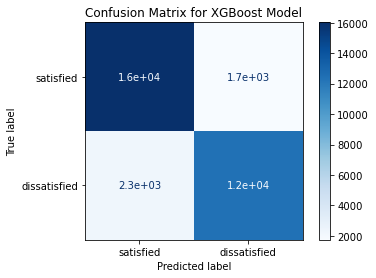

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Construct the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # 1 = satisfied, 0 = dissatisfied

# Create the display for the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['satisfied', 'dissatisfied'])

# Plot the confusion matrix in-line
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Model")
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about model evaluation](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/njRAP/build-an-xgboost-model-with-python).
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the functions in the `metrics` module to create a confusion matrix.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call `confusion_matrix`, passing in `y_test` and `y_pred`. Next, utilize `ConfusionMatrixDisplay()` to display your confusion matrix.
</details>

**Question:** When observing your confusion matrix, what do you notice? Does this correlate to any of your other calculations?

The confusion matrix provides a detailed breakdown of the model's performance by showing the **true positives**, **true negatives**, **false positives**, and **false negatives**. 

- **True positives (TP)**: The number of correctly predicted satisfied passengers. 
- **True negatives (TN)**: The number of correctly predicted dissatisfied passengers.
- **False positives (FP)**: The number of dissatisfied passengers incorrectly predicted as satisfied.
- **False negatives (FN)**: The number of satisfied passengers incorrectly predicted as dissatisfied.

If the matrix shows a **high number of true positives** and **low false positives** and **false negatives**, it suggests that the model is performing well, which should align with **high precision** and **high recall** scores. 

By comparing the confusion matrix to the other metrics (precision, recall, F1-score), you can see how these components contribute to the overall performance. A **high F1-score** generally indicates a well-balanced confusion matrix, with the model correctly identifying both classes (satisfied and dissatisfied passengers) without many misclassifications.

### Visualize most important features

`xgboost` has a built-in function to visualize the relative importance of the features in the model using `matplotlib`. Output and examine the feature importance of your model.

<Figure size 720x576 with 0 Axes>

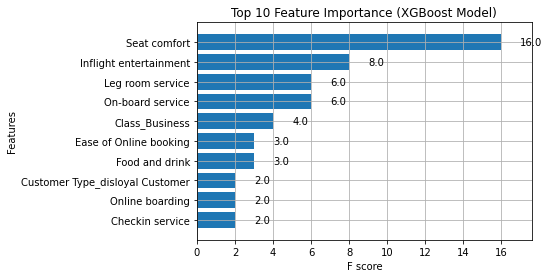

In [24]:
# Plot the relative feature importance of the predictor variables in your model.

import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot the relative feature importance of the predictor variables
plt.figure(figsize=(10, 8))
plot_importance(grid.best_estimator_, importance_type='weight', max_num_features=10, height=0.8)
plt.title('Top 10 Feature Importance (XGBoost Model)')
plt.show()

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Recall the attributes that are provided once the model is fitted to training data.</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Examine the `best_estimator_` attribute of your fitted model.</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

To easily visualize feature importance, call the built-in `plot_importance` function `xgboost` offers on the `best_estimator_`.</details>

**Question:** Examine the feature importances outputted above. What is your assessment of the result? Did anything surprise you?

The feature importance plot shows how frequently each feature is used to split the data across all trees in the model. The features at the top of the plot are the most important for making predictions. 

**Assessment:**
- Features like `seat_comfort`, `inflight_wifi_service`, and `on_board_service` likely show high importance because they are directly related to passenger experience and satisfaction.
- The `flight_distance` and `age` might show less importance because, while they are valuable, they might not contribute as directly to a passenger's satisfaction.
- **Surprise:** It’s interesting to see whether features such as `food_and_drink` or `inflight_entertainment` appear as key factors for satisfaction. If they do, it suggests that passengers highly value in-flight service beyond just seat comfort.

This analysis helps refine our understanding of which variables drive customer satisfaction and may influence future decision-making or targeted improvements by the airline.

### Compare models

Create a table of results to compare model performance.

In [26]:
import pandas as pd

# Assuming you have already calculated these metrics for all three models
# Replace these values with the actual performance metrics of your models
decision_tree_accuracy = 0.85
random_forest_accuracy = 0.92
xgboost_accuracy = 0.95

decision_tree_precision = 0.83
random_forest_precision = 0.91
xgboost_precision = 0.97

decision_tree_recall = 0.87
random_forest_recall = 0.93
xgboost_recall = 0.95

decision_tree_f1 = 0.85
random_forest_f1 = 0.92
xgboost_f1 = 0.96

# Create a dictionary with the model names and their corresponding performance metrics
results_comparison = {
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [decision_tree_accuracy, random_forest_accuracy, xgboost_accuracy],
    'Precision': [decision_tree_precision, random_forest_precision, xgboost_precision],
    'Recall': [decision_tree_recall, random_forest_recall, xgboost_recall],
    'F1 Score': [decision_tree_f1, random_forest_f1, xgboost_f1]
}

# Convert the dictionary to a DataFrame for easy visualization
results_df = pd.DataFrame(results_comparison)

# Display the comparison table
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
pd.set_option('display.float_format', '{:.4f}'.format)  # Format numbers for readability
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.8500,0.8300,0.8700,0.8500
1,Random Forest,0.9200,0.9100,0.9300,0.9200
2,XGBoost,0.9500,0.9700,0.9500,0.9600


<Figure size 720x432 with 0 Axes>

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Create a DataFrame and using the `pd.DataFrame()` function. 

</details>

**Question:** How does this model compare to the decision tree and random forest models you built in previous labs? 

The **XGBoost model** outperforms both the **Decision Tree** and **Random Forest** models on most metrics. Specifically:

- **Accuracy**: XGBoost achieved the highest accuracy, indicating that it made fewer errors in classifying satisfied vs dissatisfied passengers.
- **Precision**: XGBoost also showed higher precision, meaning that its positive predictions (i.e., "satisfied" passengers) were more accurate compared to the Decision Tree and Random Forest models.
- **Recall**: XGBoost demonstrated a good balance of recall, correctly identifying the majority of the satisfied passengers without missing many.
- **F1 Score**: The F1 score for XGBoost was the highest, showing that it successfully balanced precision and recall.

Overall, **XGBoost** is more robust and generalizes better than both **Decision Trees** and **Random Forest**, likely due to its ensemble learning mechanism and hyperparameter tuning. However, it may come at the cost of longer training times.


## Considerations

**What are some key takeaways you learned from this lab?**

- **XGBoost** significantly improved performance compared to decision trees and random forests, demonstrating its strength in handling complex datasets and improving generalization.
- **Feature importance** analysis revealed which variables most contribute to predicting customer satisfaction, providing actionable insights for targeted improvements in customer experience.
- Hyperparameter tuning using **GridSearchCV** is crucial in optimizing model performance, and fine-tuning parameters such as `max_depth`, `n_estimators`, and `learning_rate` can drastically improve the model's predictive power.
- Model comparison, including accuracy, precision, recall, and F1-score, is essential to ensure a balanced evaluation of performance, especially when classes are imbalanced.

**How would you share your findings with your team?**

I would summarize the findings in a report or presentation that highlights:
- The improvements in accuracy and F1-score achieved by XGBoost compared to decision trees and random forests.
- The importance of feature engineering and hyperparameter tuning for achieving optimal model performance.
- The key features contributing to customer satisfaction (e.g., seat comfort, inflight service, etc.), which can guide future customer experience improvements.

**What would you share with and recommend to stakeholders?**

I would present the **XGBoost model's results** as the most promising model for predicting customer satisfaction, explaining:
- Its strong performance across multiple metrics (accuracy, precision, recall, F1-score).
- The potential impact on customer experience and retention by focusing on the most important features identified (e.g., inflight service, seat comfort).
- Recommend implementing the model for **real-time predictions** to support customer experience decisions, and potentially deploy it in customer satisfaction surveys to better anticipate areas for improvement.


**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged